In [0]:
#Importing Libraries and Raw Log Data
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum, when, col, round
from pyspark.sql.functions import hour
import numpy as np

raw_log = spark.table("workspace.default.programmatic_funnel_user_level_new")

In [0]:
raw_log.count()

200000

In [0]:
# Cols which should not have null values
# user_id
# campaign_id
# creative_id
# session_id
# timestamp


In [0]:
#Dropping Nulls and Duplicates
df_silver = raw_log.where((raw_log.user_id.isNotNull())
                          & (raw_log.campaign_id.isNotNull())
                          & (raw_log.creative_id.isNotNull())
                          & (raw_log.session_id.isNotNull())
                          & (raw_log.timestamp.isNotNull())
)
df_silver = df_silver.dropDuplicates()
df_silver.count()

200000

In [0]:
#FSAs Targeted
df_silver.select('fsa').distinct().show()

+---+
|fsa|
+---+
|V6B|
|M5V|
|H3G|
|T2P|
|K1A|
+---+



In [0]:
#Adding Province and City Column
df_silver = df_silver.withColumn("city",
                                 when(col('fsa')=='V6B','Vancouver')
                                 .when(col('fsa')=='M5V','Toronto')
                                 .when(col('fsa')=='H3G','Montreal')
                                 .when(col('fsa')=='T2P','Calgary')
                                 .when(col('fsa')=='K1A','Ottawa'))

df_silver = df_silver.withColumn("province",
                                 when(col('fsa')=='V6B','British Columbia')
                                 .when(col('fsa')=='M5V','Ontario')
                                 .when(col('fsa')=='H3G','Quebec')
                                 .when(col('fsa')=='T2P','Alberta')
                                 .when(col('fsa')=='K1A','Ontario'))
                                 

In [0]:
#Observing the schema
df_silver.limit(3).display()

log_id,user_id,session_id,timestamp,day_of_week,campaign_id,campaign_objective,creative_id,creative_type,device_type,fsa,age_group,impression_count,is_click,is_conversion,vcr_percent,bid_price_usd,city,province
5de92b66-5677-4c23-a3cb-4caaf516e872,user_7296,4492768e-3a3f-4b9d-8b02-e3ab5f22cd6e,2025-01-01T12:28:14.106Z,Wednesday,C3_CONV,Conversion,C3_CONV_Video_15s,Video_15s,Desktop,V6B,18-24,1,0,0,71.94,1.5,Vancouver,British Columbia
cb5455f8-906d-442c-997a-856e8b993261,user_35741,8bc56a7e-1f42-4c02-9416-d0b7d8a55238,2025-01-03T14:52:35.871Z,Friday,C4_RETARGET,Retargeting,C4_RETARGET_Video_15s,Video_15s,Desktop,M5V,25-34,1,0,0,60.41,6.74,Toronto,Ontario
670714d8-73cf-4f10-97b6-6422574d46d9,user_15247,9d5f066d-3ac9-44c9-93e0-84cdd327e84d,2025-01-17T08:59:20.160Z,Friday,C1_AWARE,Awareness,C1_AWARE_Video_30s,Video_30s,CTV,V6B,45-54,1,0,0,94.2,2.68,Vancouver,British Columbia


In [0]:
#Campaign Types
df_silver.select('campaign_objective').distinct().show()

+------------------+
|campaign_objective|
+------------------+
|        Conversion|
|       Retargeting|
|         Awareness|
|           Traffic|
+------------------+



Conversion - Drive specific, high-value actions, such as purchases, sign-ups, or form submissions.<br>
Retargeting - Re-engage users who previously interacted with the brand but did not convert.<br>
Awareness - Inform target audiences about new products, services, or brand announcements.<br>
Traffic - Increase the volume of visitors to a website or landing page

In [0]:
#Creative Types
df_silver.select('creative_type').distinct().show()

+-------------+
|creative_type|
+-------------+
|    Video_15s|
|    Video_30s|
|Static_Banner|
+-------------+



In [0]:
#Target Devices
df_silver.select('device_type').distinct().show()

+-----------+
|device_type|
+-----------+
|    Desktop|
|        CTV|
|     Mobile|
+-----------+



In [0]:
#Age Groups
df_silver.select('age_group').distinct().show()

+---------+
|age_group|
+---------+
|    18-24|
|    25-34|
|    45-54|
|    35-44|
|      55+|
+---------+



## Analysis 

In [0]:
#Segregating df_golden by device type
df_golden_ctv = df_silver.filter(df_silver.device_type =='CTV')
df_golden_desktop = df_silver.filter(df_silver.device_type =='Desktop')
df_golden_mobile = df_silver.filter(df_silver.device_type =='Mobile')

#### 1. CTV - Primary metric - VCR

In [0]:
df_golden_ctv.count()

50077

In [0]:
#Overall Performance - CTV
df_golden_ctv.groupBy('campaign_objective').agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>90,1).otherwise(0)).alias('90 percent completion'),
    round((sum(when(col('vcr_percent')>90,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 90%'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).show()
# CTV objective was only awareness

+------------------+-----------------+---------------------+----------+---------------------+----------+
|campaign_objective|total_impressions|90 percent completion|vcr at 90%|95 percent completion|vcr at 95%|
+------------------+-----------------+---------------------+----------+---------------------+----------+
|         Awareness|            50077|                49207|     98.26|                30388|     60.68|
+------------------+-----------------+---------------------+----------+---------------------+----------+



In [0]:
#Time of Day Analysis - CTV
pdf_ctv_hour=df_golden_ctv.groupBy(hour('timestamp').alias('hour')).agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>90,1).otherwise(0)).alias('90 percent completion'),
    round((sum(when(col('vcr_percent')>90,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 90%'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).orderBy('hour').toPandas()
pdf_ctv_hour

,hour,total_impressions,90 percent completion,vcr at 90%,95 percent completion,vcr at 95%
0,0,1818,1817,99.94,830,45.65
1,1,1826,1825,99.95,844,46.22
2,2,446,234,52.47,19,4.26
3,3,459,246,53.59,13,2.83
4,4,423,216,51.06,12,2.84
5,5,420,204,48.57,13,3.10
6,6,1719,1719,100.00,808,47.00
7,7,1781,1779,99.89,829,46.55
8,8,1792,1790,99.89,849,47.38
9,9,1802,1801,99.94,798,44.28


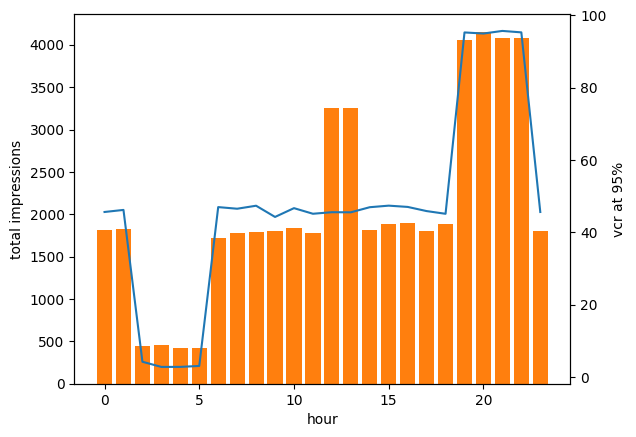

In [0]:
#TOD Graphical - CTV
fig, ax1 = plt.subplots()
ax1.bar(pdf_ctv_hour['hour'],pdf_ctv_hour['total_impressions'],color='C1')
ax1.set_xlabel('hour')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_ctv_hour['hour'],pdf_ctv_hour['vcr at 95%'])
ax2.set_ylabel('vcr at 95%')
plt.show()

In [0]:
#Day of Week - CTV
pdf_ctv_week=df_golden_ctv.groupBy('day_of_week').agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).toPandas()
cats = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pdf_ctv_week["day_of_week"] = pd.Categorical(
    pdf_ctv_week["day_of_week"],
    categories=cats,
    ordered=True
)
pdf_ctv_week = pdf_ctv_week.sort_values("day_of_week")
pdf_ctv_week

,day_of_week,total_impressions,95 percent completion,vcr at 95%
5,Monday,6408,3473,54.20
4,Tuesday,6472,3582,55.35
3,Wednesday,8044,4338,53.93
1,Thursday,7995,4268,53.38
0,Friday,8182,4430,54.14
2,Saturday,6503,5202,79.99
6,Sunday,6473,5095,78.71


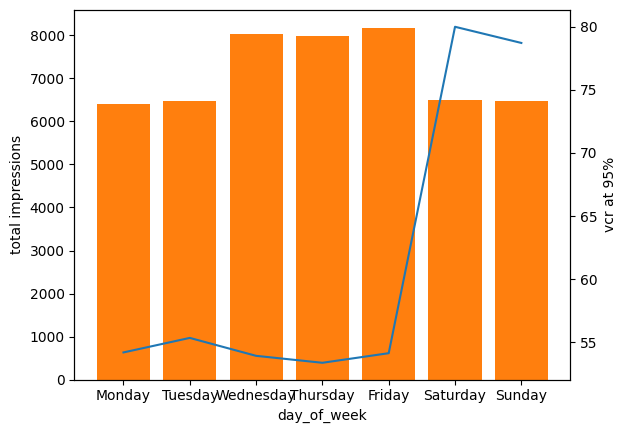

In [0]:
#DOW Graphical - CTV
fig, ax1 = plt.subplots()
ax1.bar(pdf_ctv_week['day_of_week'],pdf_ctv_week['total_impressions'],color='C1')
ax1.set_xlabel('day_of_week')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_ctv_week['day_of_week'],pdf_ctv_week['vcr at 95%'])
ax2.set_ylabel('vcr at 95%')
plt.show()

In [0]:
#Age Group - CTV
pdf_ctv_age=df_golden_ctv.groupBy('age_group').agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).orderBy('age_group').toPandas()
pdf_ctv_age

,age_group,total_impressions,95 percent completion,vcr at 95%
0,18-24,10032,6026,60.07
1,25-34,10011,6126,61.19
2,35-44,10040,6128,61.04
3,45-54,9894,5994,60.58
4,55+,10100,6114,60.53


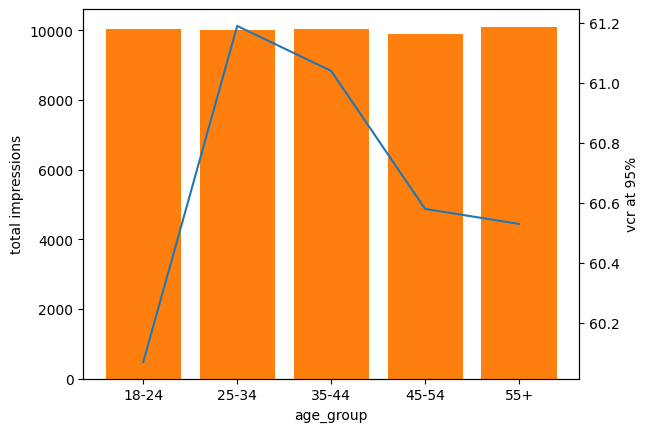

In [0]:
#Age Group Graphical - CTV
fig, ax1 = plt.subplots()
ax1.bar(pdf_ctv_age['age_group'],pdf_ctv_age['total_impressions'],color='C1')
ax1.set_xlabel('age_group')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_ctv_age['age_group'],pdf_ctv_age['vcr at 95%'])
ax2.set_ylabel('vcr at 95%')
plt.show()

In [0]:
#Creative Type - CTV
pdf_ctv_creative=df_golden_ctv.groupBy('creative_type').agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).toPandas()
pdf_ctv_creative

,creative_type,total_impressions,95 percent completion,vcr at 95%
0,Video_30s,25167,15307,60.82
1,Video_15s,24910,15081,60.54


#### Observations - CTV <br>
- Impressions and VCR peak during 7–10 PM. Although 12–1 PM brings good impressions, VCR is lower, so delivery should focus on 7–10 PM.<br>
- Weekends (Sat–Sun) have higher VCR, while Friday has the highest impressions. Weekends perform better overall.<br>
- 25–34 shows the highest VCR; 18–24 should be avoided.<br>
- 30s and 15s CTV ads show similar performance.

####2. Desktop - Primary Metric - CTR and VCR

In [0]:
df_golden_desktop.count()

75047

In [0]:
df_golden_desktop.select('creative_type').distinct().show()

+-------------+
|creative_type|
+-------------+
|    Video_15s|
|    Video_30s|
|Static_Banner|
+-------------+



In [0]:
#Segregating Static and Video Creatives
df_golden_desktop_static = df_golden_desktop.filter(col('creative_type') == 'Static_Banner')
df_golden_desktop_video = df_golden_desktop.filter(col('creative_type') != 'Static_Banner')

- Desktop - Static Banner Creative - CTR

In [0]:
df_golden_desktop_static.count()

24879

In [0]:
#Overall Performance - Desktop
df_golden_desktop_static.groupBy('campaign_objective').agg(sum('impression_count').alias('total_impression'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).show()


+------------------+----------------+------------+----+
|campaign_objective|total_impression|total_clicks| ctr|
+------------------+----------------+------------+----+
|       Retargeting|            8358|          64|0.77|
|        Conversion|           16521|         120|0.73|
+------------------+----------------+------------+----+



In [0]:
#Time of Day Analysis - Desktop
pdf_desktop_hour = df_golden_desktop_static.groupBy(hour('timestamp').alias('hour')).agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).orderBy('hour').toPandas()
pdf_desktop_hour

,hour,total_impressions,total_clicks,ctr
0,0,898,8,0.89
1,1,911,4,0.44
2,2,218,0,0.00
3,3,209,3,1.44
4,4,257,1,0.39
5,5,193,0,0.00
6,6,904,6,0.66
7,7,863,7,0.81
8,8,879,7,0.80
9,9,933,5,0.54


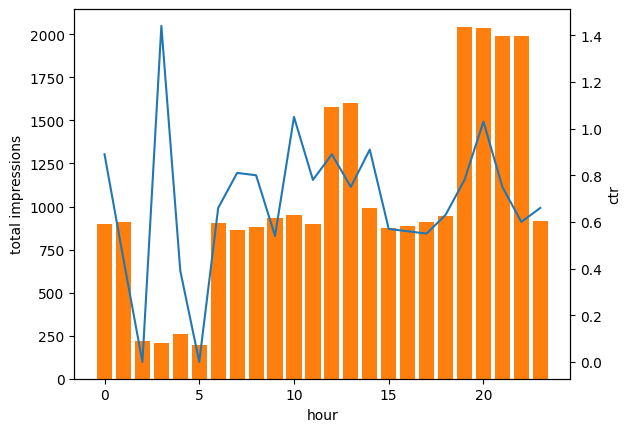

In [0]:
# Time of Day - Graphical - Desktop
fig, ax1 = plt.subplots()
ax1.bar(pdf_desktop_hour['hour'],pdf_desktop_hour['total_impressions'],color='C1')
ax1.set_xlabel('hour')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_desktop_hour['hour'],pdf_desktop_hour['ctr'])
ax2.set_ylabel('ctr')
plt.show()

In [0]:
#Day of Week Analysis - Desktop
pdf_desktop_week = df_golden_desktop_static.groupBy('day_of_week').agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

pdf_desktop_week["day_of_week"] = pd.Categorical(
    pdf_desktop_week["day_of_week"],
    categories=cats,
    ordered=True
)
pdf_desktop_week = pdf_desktop_week.sort_values("day_of_week")
pdf_desktop_week

,day_of_week,total_impressions,total_clicks,ctr
4,Monday,3197,25,0.78
6,Tuesday,3217,18,0.56
2,Wednesday,4031,32,0.79
0,Thursday,3990,26,0.65
1,Friday,4034,25,0.62
3,Saturday,3230,30,0.93
5,Sunday,3180,28,0.88


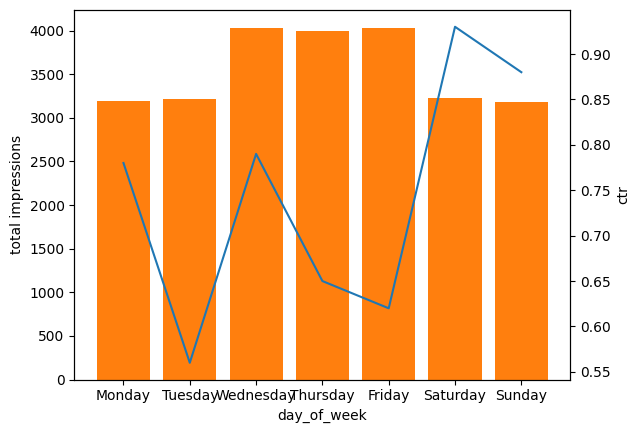

In [0]:
#Day of Week - Graphical - Desktop
fig, ax1 = plt.subplots()
ax1.bar(pdf_desktop_week['day_of_week'],pdf_desktop_week['total_impressions'],color='C1')
ax1.set_xlabel('day_of_week')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_desktop_week['day_of_week'],pdf_desktop_week['ctr'])
ax2.set_ylabel('ctr')
plt.show()

In [0]:
#Age Group - Desktop
pdf_desktop_age = df_golden_desktop_static.groupBy('age_group').agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).orderBy('age_group').toPandas()
pdf_desktop_age

,age_group,total_impressions,total_clicks,ctr
0,18-24,4923,35,0.71
1,25-34,4943,37,0.75
2,35-44,4978,38,0.76
3,45-54,5026,43,0.86
4,55+,5009,31,0.62


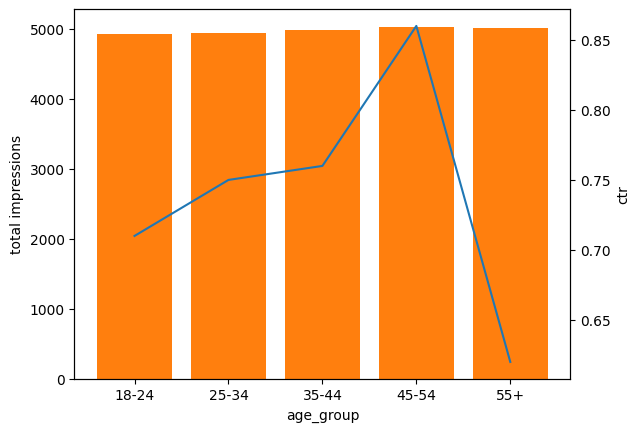

In [0]:
#Age Group - Graphical - Desktop
fig, ax1 = plt.subplots()
ax1.bar(pdf_desktop_age['age_group'],pdf_desktop_age['total_impressions'],color='C1')
ax1.set_xlabel('age_group')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_desktop_age['age_group'],pdf_desktop_age['ctr'])
ax2.set_ylabel('ctr')
plt.show()

- Desktop - Video Creative - VCR

In [0]:
# - Overall Performance - Desktop Video
df_golden_desktop_video.groupBy('campaign_objective').agg(
    sum('impression_count').alias('total_impressions'),
    sum(when(col('vcr_percent')>90,1).otherwise(0)).alias('90 percent completion'),
    round((sum(when(col('vcr_percent')>90,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 90%'),
    sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
    round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')
).show()

+------------------+-----------------+---------------------+----------+---------------------+----------+
|campaign_objective|total_impressions|90 percent completion|vcr at 90%|95 percent completion|vcr at 95%|
+------------------+-----------------+---------------------+----------+---------------------+----------+
|        Conversion|            33462|                    0|       0.0|                    0|       0.0|
|       Retargeting|            16706|                    0|       0.0|                    0|       0.0|
+------------------+-----------------+---------------------+----------+---------------------+----------+



VCR is generally not calculated on mobile and desktop campaigns

#### Observations - Desktop <br>
- Best CTR occurs at 8 PM on weekends. Impressions peak during 7–10 PM (Wed–Fri) but CTR is lower.
- 45–54 age group shows the strongest performance in both impressions and CTR.

#### 3. Mobile - CTR

In [0]:
#Overall Performance - Mobile
df_golden_mobile.groupBy('campaign_objective').agg(sum('impression_count').alias('total_impression'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).show()


+------------------+----------------+------------+----+
|campaign_objective|total_impression|total_clicks| ctr|
+------------------+----------------+------------+----+
|           Traffic|           49898|         995|1.99|
|       Retargeting|           24978|         367|1.47|
+------------------+----------------+------------+----+



In [0]:
#Time of Day Analysis - Mobile
pdf_mobile_hour = df_golden_mobile.groupBy(hour('timestamp').alias('hour')).agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).orderBy('hour').toPandas()
pdf_mobile_hour

,hour,total_impressions,total_clicks,ctr
0,0,2613,46,1.76
1,1,2827,42,1.49
2,2,646,10,1.55
3,3,741,11,1.48
4,4,650,9,1.38
5,5,688,9,1.31
6,6,2691,47,1.75
7,7,2714,38,1.40
8,8,2802,50,1.78
9,9,2747,43,1.57


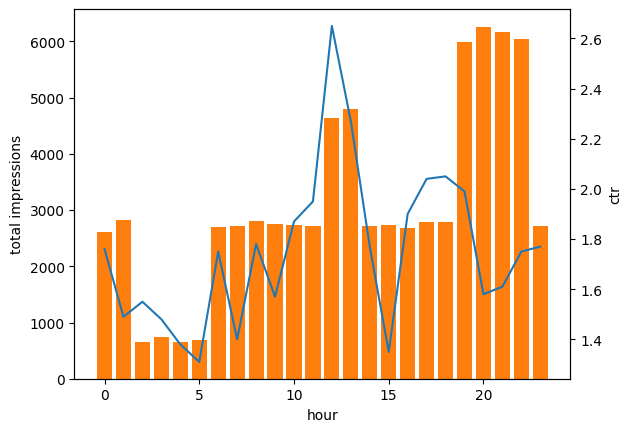

In [0]:
#Time of Day Analysis - Graphical - Mobile
fig, ax1 = plt.subplots()
ax1.bar(pdf_mobile_hour['hour'],pdf_mobile_hour['total_impressions'],color='C1')
ax1.set_xlabel('hour')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_mobile_hour['hour'],pdf_mobile_hour['ctr'])
ax2.set_ylabel('ctr')
plt.show()

In [0]:
#Day of Week Analysis - Mobile
pdf_mobile_week = df_golden_mobile.groupBy('day_of_week').agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

pdf_mobile_week["day_of_week"] = pd.Categorical(
    pdf_mobile_week["day_of_week"],
    categories=cats,
    ordered=True
)
pdf_mobile_week = pdf_mobile_week.sort_values("day_of_week")
pdf_mobile_week

,day_of_week,total_impressions,total_clicks,ctr
5,Monday,9617,168,1.75
1,Tuesday,9533,185,1.94
4,Wednesday,12113,210,1.73
2,Thursday,12170,200,1.64
3,Friday,11974,222,1.85
6,Saturday,9673,186,1.92
0,Sunday,9796,191,1.95


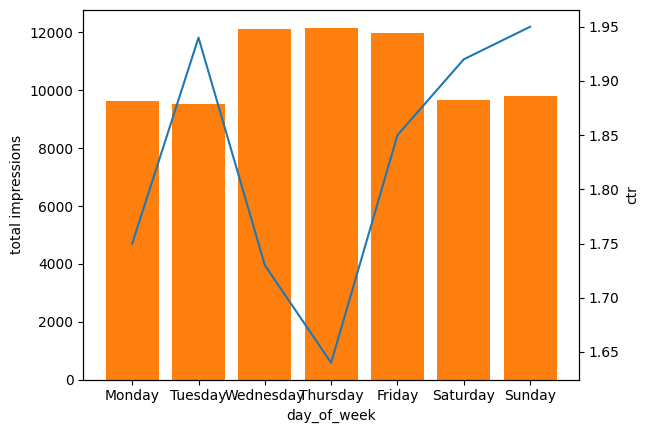

In [0]:
#Day of Week Analysis - Graphical - Mobile
fig, ax1 = plt.subplots()
ax1.bar(pdf_mobile_week['day_of_week'],pdf_mobile_week['total_impressions'],color='C1')
ax1.set_xlabel('day_of_week')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_mobile_week['day_of_week'],pdf_mobile_week['ctr'])
ax2.set_ylabel('ctr')
plt.show()

In [0]:
#Age Group - Mobile
pdf_mobile_age = df_golden_mobile.groupBy('age_group').agg(sum('impression_count').alias('total_impressions'),
                                                    sum('is_click').alias('total_clicks'),
                                                    round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).orderBy('age_group').toPandas()
pdf_mobile_age

,age_group,total_impressions,total_clicks,ctr
0,18-24,14884,253,1.70
1,25-34,14947,291,1.95
2,35-44,15051,271,1.80
3,45-54,14864,282,1.90
4,55+,15130,265,1.75


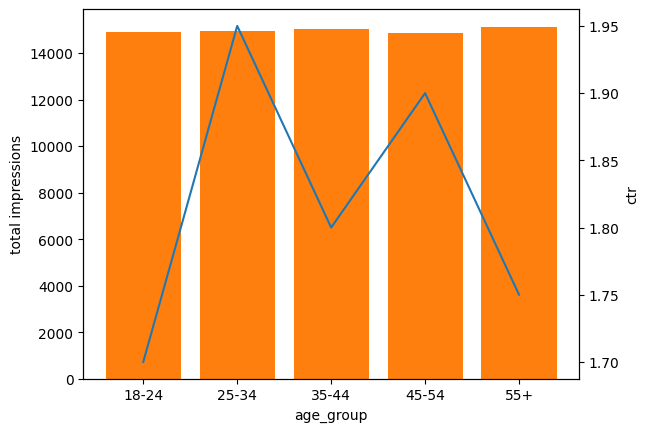

In [0]:
#Age Group - Graphical - Mobile
fig, ax1 = plt.subplots()
ax1.bar(pdf_mobile_age['age_group'],pdf_mobile_age['total_impressions'],color='C1')
ax1.set_xlabel('age_group')
ax1.set_ylabel('total impressions')
ax2 = ax1.twinx()
ax2.plot(pdf_mobile_age['age_group'],pdf_mobile_age['ctr'])
ax2.set_ylabel('ctr')
plt.show()

#### Observations - Mobile <br>
- Impressions peak during 7–10 PM, but CTR is higher at 12–1 PM, so focus should shift to 12–1 PM.
- Weekends and Tuesday have the best CTR. Impressions from Wed–Fri should be shifted to Sat, Sun, and Tue.
- Adults and middle-aged users lead in impressions and CTR, but ads are currently targeted similarly across all age groups.


####Geographical Analysis

In [0]:
#Selecting columns relevant to Geographical Analysis
df_geo_ctv = df_golden_ctv.select('campaign_id','device_type','fsa','province','city','impression_count','is_click','vcr_percent')
df_geo_mobile = df_golden_mobile.select('campaign_id','device_type','fsa','province','city','impression_count','is_click','vcr_percent')
df_geo_desktop = df_golden_desktop.select('campaign_id','device_type','fsa','province','city','impression_count','is_click','vcr_percent')

In [0]:
#City and Province Wise - CTV
pdf_city_ctv = df_geo_ctv.groupBy('city').agg(sum('impression_count').alias('total_impressions'),
                                        sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
                                        round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')).toPandas()

pdf_province_ctv = df_geo_ctv.groupBy('province').agg(sum('impression_count').alias('total_impressions'),
                                        sum(when(col('vcr_percent')>95,1).otherwise(0)).alias('95 percent completion'),
                                        round((sum(when(col('vcr_percent')>95,1).otherwise(0))/sum('impression_count'))*100,2).alias('vcr at 95%')).toPandas()


In [0]:
pdf_city_ctv

,city,total_impressions,95 percent completion,vcr at 95%
0,Vancouver,10075,6128,60.82
1,Montreal,10079,6140,60.92
2,Toronto,9874,5992,60.68
3,Ottawa,10044,6021,59.95
4,Calgary,10005,6107,61.04


In [0]:
pdf_province_ctv

,province,total_impressions,95 percent completion,vcr at 95%
0,British Columbia,10075,6128,60.82
1,Quebec,10079,6140,60.92
2,Ontario,19918,12013,60.31
3,Alberta,10005,6107,61.04


In [0]:
#City and Province Wise - Desktop
pdf_city_desktop = df_geo_desktop.groupBy('city').agg(sum('impression_count').alias('total_impressions'),
                                                sum('is_click').alias('total_clicks'),
                                                round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

pdf_province_desktop = df_geo_desktop.groupBy('province').agg(sum('impression_count').alias('total_impressions'),
                                                sum('is_click').alias('total_clicks'),
                                                round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

In [0]:
pdf_city_desktop

,city,total_impressions,total_clicks,ctr
0,Vancouver,14874,115,0.77
1,Toronto,15198,124,0.82
2,Calgary,14944,93,0.62
3,Montreal,15135,104,0.69
4,Ottawa,14896,111,0.75


In [0]:
pdf_province_desktop

,province,total_impressions,total_clicks,ctr
0,British Columbia,14874,115,0.77
1,Ontario,30094,235,0.78
2,Alberta,14944,93,0.62
3,Quebec,15135,104,0.69


In [0]:
#City and Province Wise - Mobile
pdf_city_mobile = df_geo_mobile.groupBy('city').agg(sum('impression_count').alias('total_impressions'),
                                                sum('is_click').alias('total_clicks'),
                                                round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

pdf_province_mobile = df_geo_mobile.groupBy('province').agg(sum('impression_count').alias('total_impressions'),
                                                sum('is_click').alias('total_clicks'),
                                                round((sum('is_click')/sum('impression_count'))*100,2).alias('ctr')).toPandas()

In [0]:
pdf_city_mobile

,city,total_impressions,total_clicks,ctr
0,Vancouver,14828,270,1.82
1,Montreal,15236,255,1.67
2,Calgary,14900,291,1.95
3,Ottawa,15006,262,1.75
4,Toronto,14906,284,1.91


In [0]:
pdf_province_mobile

,province,total_impressions,total_clicks,ctr
0,British Columbia,14828,270,1.82
1,Quebec,15236,255,1.67
2,Alberta,14900,291,1.95
3,Ontario,29912,546,1.83


####Observations <br>
####CTV

- Calgary has the highest VCR, though the difference across cities is minimal.
- Alberta leads provinces with 61.04% VCR, but differences are small.

####Desktop

- Toronto has the highest CTR (0.82). Impressions are similar across cities, so targeting should increase impressions in better-performing cities.
- Ontario has the best provincial CTR (0.78), followed by BC (0.77), though BC has significantly fewer impressions.

####Mobile

- Calgary and Toronto have the highest CTR; impressions could be increased in these cities.
- Alberta performs best provincially with 1.95 CTR.